# **Meeeeeee**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:

data = '/kaggle/input/usa-real-estate-dataset/realtor-data.zip.csv'
df = pd.read_csv(data)

# Select a random sample of 50,000 rows
df = df.sample(n=1000_000, random_state=42)

# Now sample_df contains 50,000 random rows from the original dataframe

In [ ]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
1696936,54239.0,sold,275000.0,1.0,1.0,NaN,1617038.0,Miami,Florida,33156.0,846.0,2022-02-28
2092671,90564.0,sold,399900.0,1.0,1.0,NaN,1497499.0,San Diego,California,92108.0,667.0,2022-04-28
742044,53271.0,for_sale,75000.0,NaN,NaN,2.25,1877529.0,Oceola Township,Michigan,48855.0,NaN,NaN
1424136,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0,2021-11-29
812329,79221.0,for_sale,169900.0,NaN,NaN,3.70,1998116.0,Holmen,Wisconsin,54636.0,NaN,NaN


In [ ]:
cols=df.columns

In [ ]:
df.shape

(1000000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 1696936 to 704136
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   brokered_by     998009 non-null   float64
 1   status          1000000 non-null  object 
 2   price           999293 non-null   float64
 3   bed             783943 non-null   float64
 4   bath            770338 non-null   float64
 5   acre_lot        854026 non-null   float64
 6   street          995172 non-null   float64
 7   city            999343 non-null   object 
 8   state           999995 non-null   object 
 9   zip_code        999855 non-null   float64
 10  house_size      744784 non-null   float64
 11  prev_sold_date  670444 non-null   object 
dtypes: float64(8), object(4)
memory usage: 99.2+ MB


In [ ]:
print(round(df.describe()),2)

       brokered_by         price       bed      bath  acre_lot     street  \
count     998009.0  9.992930e+05  783943.0  770338.0  854026.0   995172.0   
mean       52946.0  5.231600e+05       3.0       2.0      15.0  1011996.0   
std        30639.0  1.818298e+06       1.0       2.0     766.0   583824.0   
min            0.0  0.000000e+00       1.0       1.0       0.0        0.0   
25%        23893.0  1.650000e+05       3.0       2.0       0.0   506090.0   
50%        52882.0  3.250000e+05       3.0       2.0       0.0  1012114.0   
75%        79195.0  5.500000e+05       4.0       3.0       1.0  1520605.0   
max       110142.0  1.000000e+09     210.0     752.0  100000.0  2001357.0   

       zip_code  house_size  
count  999855.0    744784.0  
mean    52169.0      2058.0  
std     28950.0      4520.0  
min         0.0       100.0  
25%     29617.0      1300.0  
50%     48329.0      1760.0  
75%     78070.0      2411.0  
max     99999.0   1560780.0   2


In [ ]:
df.duplicated().sum()

0

In [ ]:
cat = [var for var in df.columns if df[var].dtype=='O']
cat

['status', 'city', 'state', 'prev_sold_date']

In [ ]:
for var in cat:

    print(df[var].value_counts())

status
for_sale          623988
sold              364801
ready_to_build     11211
Name: count, dtype: int64
city
Houston          10745
Chicago           8177
New York City     5616
Jacksonville      5259
Philadelphia      4686
                 ...  
Prathersville        1
Sumerco              1
Gotham               1
Doon                 1
Owls Head            1
Name: count, Length: 17722, dtype: int64
state
Florida                 112245
California              101920
Texas                    93283
New York                 46250
Illinois                 38598
North Carolina           38442
Georgia                  36539
Pennsylvania             35537
Arizona                  32780
Virginia                 30729
Washington               28042
Ohio                     26645
New Jersey               21630
Maryland                 20579
Missouri                 20247
Minnesota                19492
Michigan                 19107
Wisconsin                19088
South Carolina           1896

In [ ]:
df[cat].isnull().sum()

status                 0
city                 657
state                  5
prev_sold_date    329556
dtype: int64

In [ ]:
df.drop('prev_sold_date',axis=1 ,inplace=True)

In [ ]:
cat1=['status', 'city', 'state']

In [ ]:
df = df.dropna(subset=['city','state'])

In [ ]:
df[cat1].isnull().sum()

status    0
city      0
state     0
dtype: int64

In [ ]:
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
1696936,54239.0,sold,275000.0,1.0,1.0,NaN,1617038.0,Miami,Florida,33156.0,846.0
2092671,90564.0,sold,399900.0,1.0,1.0,NaN,1497499.0,San Diego,California,92108.0,667.0
742044,53271.0,for_sale,75000.0,NaN,NaN,2.25,1877529.0,Oceola Township,Michigan,48855.0,NaN
1424136,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0
812329,79221.0,for_sale,169900.0,NaN,NaN,3.70,1998116.0,Holmen,Wisconsin,54636.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2102666,57658.0,sold,265000.0,1.0,2.0,0.02,1371254.0,Palm Springs,California,92264.0,705.0
2135067,23136.0,sold,759888.0,2.0,2.0,NaN,122269.0,Milpitas,California,95035.0,1146.0
1244604,33714.0,for_sale,29500.0,NaN,NaN,4.81,1885544.0,Roswell,New Mexico,88201.0,NaN
705528,21363.0,for_sale,34900.0,2.0,1.0,0.11,1231206.0,Cleveland,Ohio,44128.0,711.0


In [ ]:
print('city contains', len(df.city.unique()), 'labels')

city contains 17721 labels


In [ ]:
print('state contains', len(df.state.unique()), 'labels')

state contains 55 labels


In [ ]:
# Calculate frequency of each city
frequency_encoding = df['status'].value_counts(normalize=True)

# Map frequency to each city
df['status'] = df['status'].map(frequency_encoding)

In [ ]:
# Calculate frequency of each city
frequency_encoding = df['city'].value_counts(normalize=True)

# Map frequency to each city
df['city'] = df['city'].map(frequency_encoding)

In [ ]:
# Calculate frequency of each city
frequency_encoding = df['state'].value_counts(normalize=True)

# Map frequency to each city
df['state'] = df['state'].map(frequency_encoding)

In [ ]:
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
1696936,54239.0,0.365001,275000.0,1.0,1.0,NaN,1617038.0,0.004355,0.112147,33156.0,846.0
2092671,90564.0,0.365001,399900.0,1.0,1.0,NaN,1497499.0,0.003226,0.101932,92108.0,667.0
742044,53271.0,0.623786,75000.0,NaN,NaN,2.25,1877529.0,0.000012,0.019111,48855.0,NaN
1424136,12926.0,0.365001,325000.0,3.0,2.0,0.09,892999.0,0.000414,0.017048,1603.0,1409.0
812329,79221.0,0.623786,169900.0,NaN,NaN,3.70,1998116.0,0.000066,0.019078,54636.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2102666,57658.0,0.365001,265000.0,1.0,2.0,0.02,1371254.0,0.000511,0.101932,92264.0,705.0
2135067,23136.0,0.365001,759888.0,2.0,2.0,NaN,122269.0,0.000175,0.101932,95035.0,1146.0
1244604,33714.0,0.623786,29500.0,NaN,NaN,4.81,1885544.0,0.000300,0.009462,88201.0,NaN
705528,21363.0,0.623786,34900.0,2.0,1.0,0.11,1231206.0,0.002638,0.026662,44128.0,711.0


In [ ]:
#pd.get_dummies(df[cat1], drop_first=True).head()

In [ ]:
num = [var for var in df.columns if df[var].dtype!='O']
len(num)

11

In [ ]:
for var in num:

    print(df[var].value_counts())

brokered_by
22611.0    20739
16829.0    12458
53016.0     9820
23592.0     4025
30807.0     3803
           ...  
27404.0        1
26208.0        1
95965.0        1
97946.0        1
98918.0        1
Name: count, Length: 87707, dtype: int64
status
0.623786    623373
0.365001    364759
0.011213     11206
Name: count, dtype: int64
price
250000.0     6977
350000.0     6835
325000.0     6381
225000.0     6272
450000.0     5955
             ... 
60150.0         1
350654.0        1
285550.0        1
402775.0        1
5285000.0       1
Name: count, Length: 58261, dtype: int64
bed
3.0      338513
4.0      198074
2.0      139597
5.0       54076
1.0       29256
          ...  
142.0         1
69.0          1
111.0         1
114.0         1
88.0          1
Name: count, Length: 81, dtype: int64
bath
2.0      334895
3.0      212083
1.0      117037
4.0       70593
5.0       20384
          ...  
47.0          1
163.0         1
97.0          1
88.0          1
68.0          1
Name: count, Length: 68, d

In [ ]:
df[num].isnull().sum()

brokered_by      1989
status              0
price             705
bed            215584
bath           229184
acre_lot       145938
street           4789
city                0
state               0
zip_code           94
house_size     254734
dtype: int64

In [ ]:
rows_with_all_nulls = df[df[['bed', 'bath', 'acre_lot','house_size','price']].isnull().all(axis=1)]
rows_with_all_nulls

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
716101,14187.0,0.623786,NaN,NaN,NaN,NaN,1138310.0,0.000279,0.026662,45822.0,NaN
278699,4190.0,0.623786,NaN,NaN,NaN,NaN,1664305.0,0.000212,0.038463,27310.0,NaN
277140,16149.0,0.623786,NaN,NaN,NaN,NaN,35135.0,0.000089,0.038463,27021.0,NaN
892387,95777.0,0.623786,NaN,NaN,NaN,NaN,1848007.0,0.000016,0.038618,61443.0,NaN
278697,4190.0,0.623786,NaN,NaN,NaN,NaN,1664075.0,0.000212,0.038463,27310.0,NaN
283557,4190.0,0.623786,NaN,NaN,NaN,NaN,1123865.0,0.000943,0.038463,27407.0,NaN
512291,96900.0,0.623786,NaN,NaN,NaN,NaN,22198.0,0.000009,0.112147,33493.0,NaN
337942,99270.0,0.623786,NaN,NaN,NaN,NaN,1948141.0,0.000074,0.018977,29118.0,NaN
277368,16149.0,0.623786,NaN,NaN,NaN,NaN,942829.0,0.000089,0.038463,27021.0,NaN
283541,4190.0,0.623786,NaN,NaN,NaN,NaN,1146268.0,0.000943,0.038463,27407.0,NaN


In [ ]:
df = df.dropna(subset=['brokered_by','price','bed','bath','acre_lot','street','zip_code','house_size'])

In [ ]:
#indices_to_drop = rows_with_all_nulls.index

#df = df.drop(indices_to_drop)

In [ ]:
print('brokered_by contains', len(df.brokered_by.unique()), 'labels')

brokered_by contains 69768 labels


In [ ]:
print('price contains', len(df.price.unique()), 'labels')

price contains 36718 labels


In [ ]:
print('bed contains', len(df.bed.unique()), 'labels')

bed contains 66 labels


In [ ]:
print('bath contains', len(df.bath.unique()), 'labels')

bath contains 57 labels


In [ ]:
print('acre_lot contains', len(df.acre_lot.unique()), 'labels')

acre_lot contains 5968 labels


In [ ]:
print('street contains', len(df.street.unique()), 'labels')

street contains 586357 labels


In [ ]:
print('zip_code contains', len(df.zip_code.unique()), 'labels')

zip_code contains 25103 labels


In [ ]:
print('house_size contains', len(df.house_size.unique()), 'labels')

house_size contains 9440 labels


In [ ]:
df = df.dropna(subset=['price','zip_code','brokered_by','bed','bath','acre_lot','street','house_size'])

In [ ]:
#df.drop('street',axis=1,inplace=True)

In [ ]:
df['bed'] = df['bed'].fillna(df['bed'].mean())

df['bath'] = df['bath'].fillna(df['bath'].mean())

df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].mean())

df['house_size'] = df['house_size'].fillna(df['house_size'].mean())

df['price'] = df['price'].fillna(df['price'].mean())

df['street'] = df['street'].fillna(df['street'].mode()[0])

df['zip_code'] = df['zip_code'].fillna(df['zip_code'].mode()[0])

df['brokered_by'] = df['brokered_by'].fillna(df['brokered_by'].mode()[0])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 608802 entries, 1424136 to 705528
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   brokered_by  608802 non-null  float64
 1   status       608802 non-null  float64
 2   price        608802 non-null  float64
 3   bed          608802 non-null  float64
 4   bath         608802 non-null  float64
 5   acre_lot     608802 non-null  float64
 6   street       608802 non-null  float64
 7   city         608802 non-null  float64
 8   state        608802 non-null  float64
 9   zip_code     608802 non-null  float64
 10  house_size   608802 non-null  float64
dtypes: float64(11)
memory usage: 55.7 MB


In [ ]:
df.isnull().sum()

brokered_by    0
status         0
price          0
bed            0
bath           0
acre_lot       0
street         0
city           0
state          0
zip_code       0
house_size     0
dtype: int64

In [ ]:
def diagnostic_plots(df, variable,target):
    # The function takes a dataframe (df) and
    # the variable of interest as arguments.

    # Define figure size.
    plt.figure(figsize=(20, 7))



    # boxplot
    plt.subplot(1, 4, 3)
    sns.boxplot(y=df[variable],color = 'b')
    plt.title('Boxplot')



    plt.show()


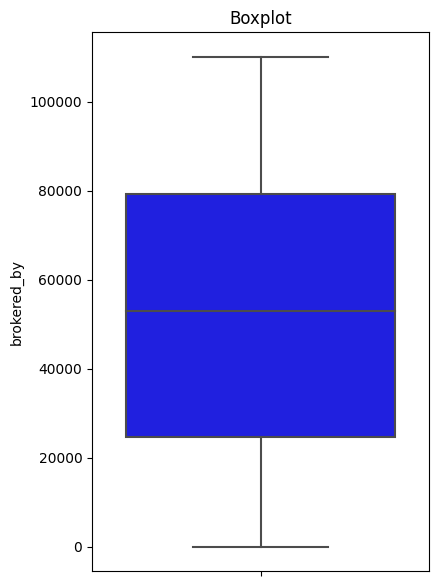

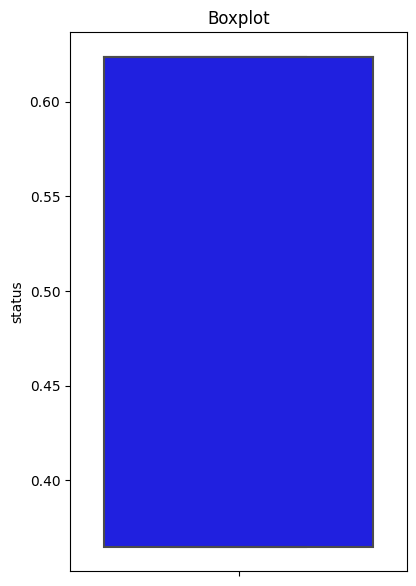

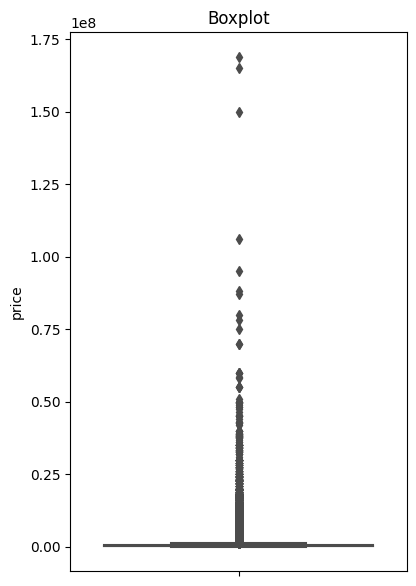

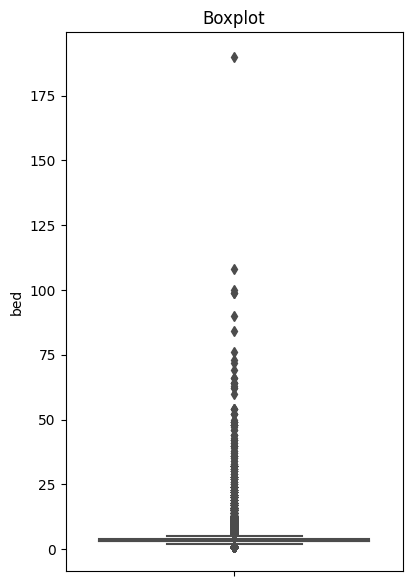

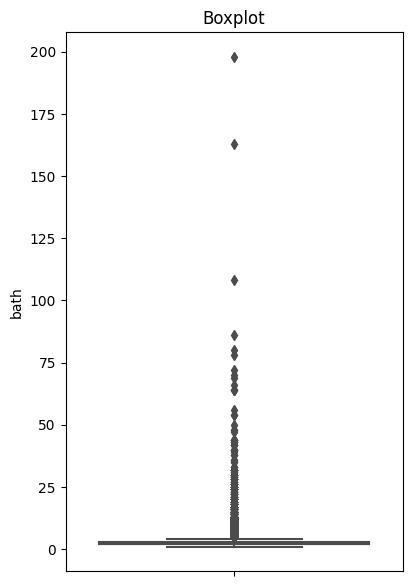

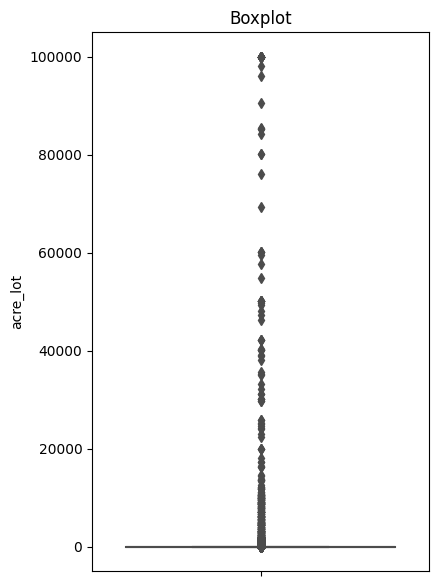

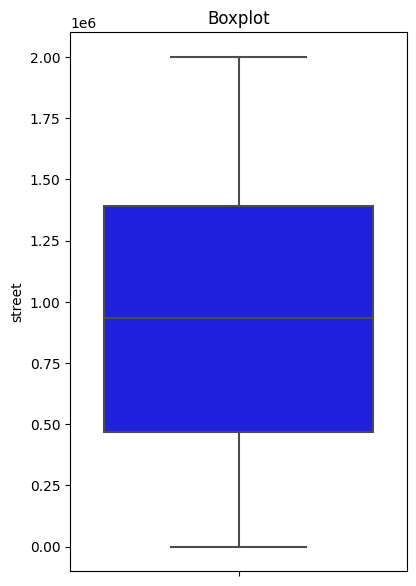

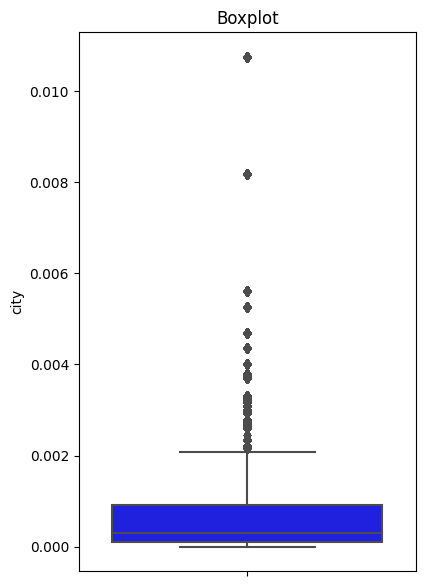

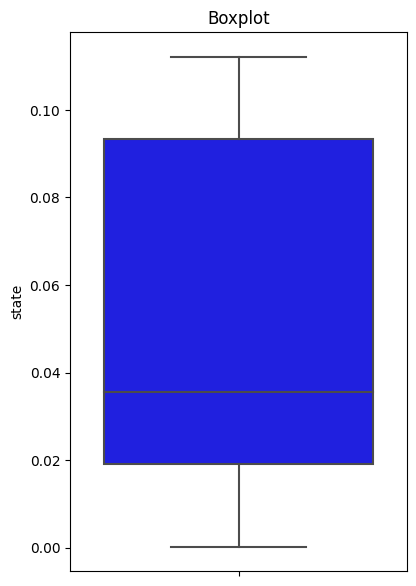

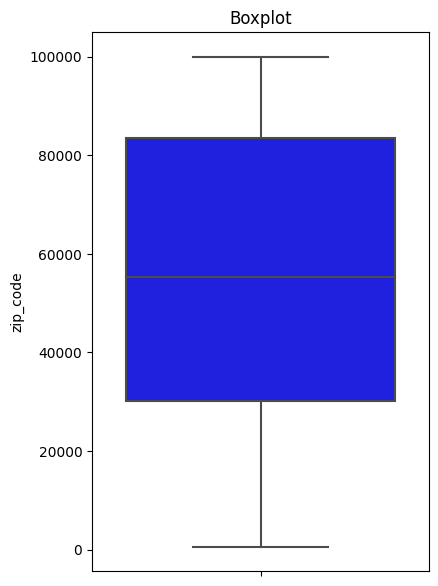

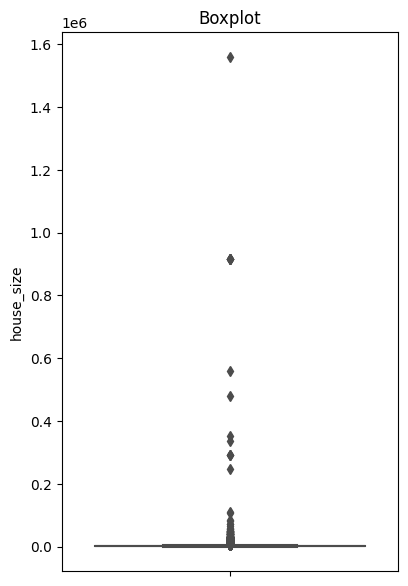

In [ ]:
for col in df:
    diagnostic_plots(df,col,'price')

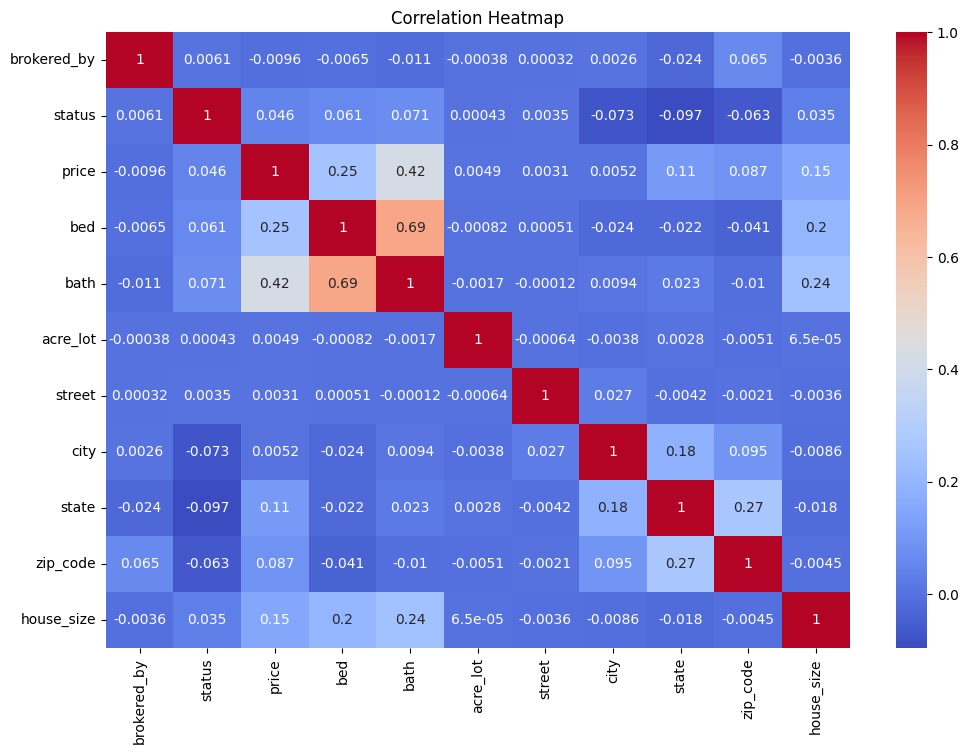

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:


# Calculate IQR for each column
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

# Separate cleaned data back into X and y
X = data_cleaned.drop('price', axis=1)  # replace 'target_column' with the actual target column name
y = data_cleaned['price']  # replace 'target_column' with the actual target column name


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df is your DataFrame
#X = df.drop('price', axis=1)
#y = df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the scaler, then transform both train and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the ANN model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))  # Use 'sigmoid' for classification

model.compile(optimizer='adam', loss='mean_squared_error')  # Change loss for classification

# Train the model
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 90393419776.0000 - val_loss: 27763058688.0000
Epoch 2/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 27000356864.0000 - val_loss: 25090088960.0000
Epoch 3/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 25104328704.0000 - val_loss: 24160872448.0000
Epoch 4/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 24167843840.0000 - val_loss: 23728982016.0000
Epoch 5/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 23840000000.0000 - val_loss: 23356917760.0000
Epoch 6/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 23516485632.0000 - val_loss: 23046625280.0000
Epoch 7/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 23210031104.0000 - val_loss: 22800521216.0000
Epoch 8/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 22829688832.0000 - val_loss: 22585694208.0000
Epoch 9/100
7778/7778 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 22773700608.0000 - val_loss: 22475362304.0000
Epoch 10/1

In [ ]:
# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse}")


2431/2431 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Mean Squared Error on Test Set: 19171307139.770367

First 5 Predicted vs Actual values:
